In [33]:
!pip install imageio
!pip install pytorch_lightning wandb einops matplotlib
import imageio

# # Connect to GDrive
# from google.colab import drive
# drive.mount('/content/drive')

In [34]:
# !cp data.zip /data.zip
# !unzip /data.zip

In [35]:
import pickle
import sys
from math import floor
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pytorch_lightning as pl
import torch
import torch.nn as nn
import wandb
import sys
from torch import nn
from torch.utils.data import ConcatDataset, DataLoader, TensorDataset
import random
import pandas as pd

# Описание задачи

 Такие алгоритмы планирования как Model Predictive Control (MPC) могут обеспечить локальное планирование движения мобильных роботизированных платформ. Для их функционирования необходимо аналитическое представление потенциала в каждой точке, который представляет из себя стоимость столкновения для случая когда и карта препятствий, и след робота произвольны.

 В данной задаче предлагается построить модель нейронной сети,  которая возвращает дифференцируемую стоимость столкновения на 5 последующих шагов в зависимости от позы робота и предыдущих 5 карт препятствий.


# Загрузка обучающих данных

В качестве данных для обучения предлагается набор из 50 карт и 10000 точек с позицией агента и со значениями потенциалов для каждой карты.

В массиве train_maps лежат карты размера (50,50). Размерность 11 это фрэймы движения динамического препятствия на карте.

В массиве train_data лежат координаты точек (X,Y,Theta) для которых известен потенциал, который необходимо предсказать. Размерность 4 это различные вариации ориентации робота в данной точке.

В массиве train_answers лежат значения потенциалов для всех точек массива train_data.


In [36]:
base_path = "./data"

train_maps.shape (50, 11, 50, 50)
train_data.shape (50, 11, 2500, 4, 3)
train_answers.shape (50, 11, 2500, 4)


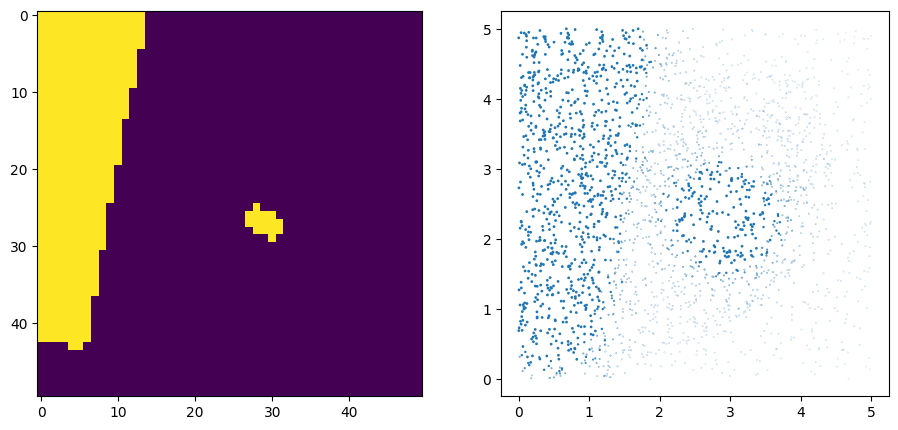

In [37]:
train_maps = np.load(base_path + "/train_data/train_maps.npy")
train_data = np.load(base_path + "/train_data/train_data.npy")
train_answers = np.load(base_path + "/train_data/train_answers.npy")

print('train_maps.shape', train_maps.shape)
print('train_data.shape', train_data.shape)
print('train_answers.shape', train_answers.shape)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11,5))

id_map = 1
id_step = 6
id_theta = 0

ax1.imshow(train_maps[id_map][id_step])
ax2.scatter(
    x=train_data[id_map, id_step, :, id_theta, 0],
    y=train_data[id_map, id_step, :, id_theta, 1],
    s=train_answers[id_map, id_step, :, id_theta],
)

In [38]:
from matplotlib import colors
import matplotlib.animation as animation

def gif_generate(data, answers, filename='test_potentials'):
    fig = plt.figure()
    ax = fig.add_subplot(111, aspect='equal', autoscale_on=False, xlim=(0, 5), ylim=(0, 5))
    x = data[0,:,0,0]
    y = data[0,:,0,1]
    z = answers[:,0]
    s = ax.scatter(x, y, c=z, cmap='viridis', s=10)
    cb = fig.colorbar(s)
    cax = cb.ax

    def animate(i):
        ax.clear()
        cax.cla()
        ax.set_xlim(0,5)
        ax.set_ylim(0,5)
        ax.set_xlabel('x [m]')
        ax.set_ylabel('y [m]')
        x = data[i,:,0,0]
        y = data[i,:,0,1]
        z = answers[:,i]
        s = ax.scatter(x, y, c=z, cmap='viridis', s=z)
        fig.colorbar(s, cax=cax)

    ani = animation.FuncAnimation(fig, animate, interval=500, frames=len(data))
    ani.save(f'{filename}.gif', writer='pillow')

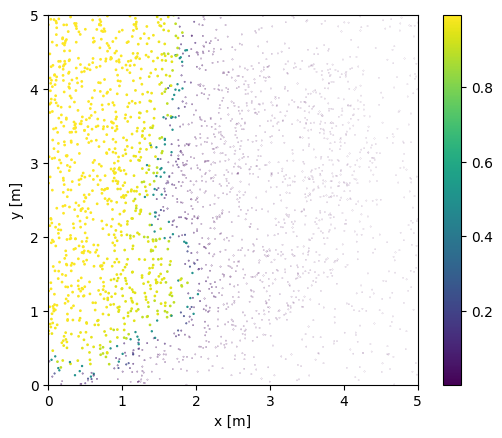

In [39]:
# Файл .gif сохраняется в рабочей папке
map_id = 1
gif_generate(train_data[map_id,:], np.transpose(train_answers[map_id, :, :,0]),
             filename='train_answers')

In [40]:
val_maps = np.load(base_path + "/val_data/val_maps.npy")
val_data = np.load(base_path + "/val_data/val_data.npy")
val_answers = np.load(base_path + "/val_data/val_answers.npy")

print('val_maps.shape', val_maps.shape)
print('val_data.shape', val_data.shape)
print('val_answers.shape', val_answers.shape)

val_maps.shape (5, 11, 50, 50)
val_data.shape (5, 11, 250, 4, 3)
val_answers.shape (5, 11, 250, 4)


In [41]:
import torch
from torch.utils.data import Dataset, DataLoader

def get_indices(single_index, coef):
    i0 = single_index // (4 * coef)
    i1 = (single_index % (coef * 4))//4
    i2 = single_index % 4

    return i0, i1, i2

class MyDataset(Dataset):
    def __init__(self, maps, data, answers=None):
        self.maps = maps
        self.data = data
        self.answers = answers

    def __getitem__(self, index):

        map_id, point_id, theta_id = get_indices(index, self.data.shape[2])

        map_input = torch.tensor(self.maps[map_id, 0:5]).float() / 100.

        input_x = torch.tensor(self.data[map_id, 0, point_id, theta_id, 0]).float()
        input_y = torch.tensor(self.data[map_id, 0, point_id, theta_id, 1]).float()
        theta = torch.tensor(self.data[map_id, 0, point_id, theta_id, 2]).float()

        output = torch.clamp(
            torch.tensor(self.answers[map_id, 6:, point_id, theta_id]).float(),
            min=0.,
            max=1
        )

        return {
            "input": (map_input, input_x.unsqueeze(0), input_y.unsqueeze(0), theta.unsqueeze(0)),
            "output": output
        }

    def __len__(self):
        return self.data.shape[0]*self.data.shape[2]*self.data.shape[3]

In [42]:
train_dataset = MyDataset(
    train_maps,
    train_data,
    train_answers
)

val_dataset = MyDataset(
    val_maps,
    val_data,
    val_answers
)

loader = DataLoader(train_dataset, batch_size=4, num_workers=1, shuffle=True)

for batch in loader:
    print(
        batch["input"][0].shape,
        batch["input"][1].shape,
        batch["input"][2].shape,
        batch["input"][3].shape,
        batch["output"].shape,
    )
    break

torch.Size([4, 5, 50, 50]) torch.Size([4, 1]) torch.Size([4, 1]) torch.Size([4, 1]) torch.Size([4, 5])


# Определим нейронную сеть

В качестве примера, ниже реализована полносвязная нейронная сеть для решения данной задачи

In [43]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import torch
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        # Convolutional encoder for map (shape: [batch, 5, 50, 50])
        self.conv1 = nn.Conv2d(5, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)  # Downsample to 25x25

        # Flatten and project map features
        self.map_fc = nn.Linear(64 * 25 * 25, 256)

        # Position embedding (x and y) - input shape [batch, 2]
        self.pos_embed = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, 64)
        )

        # Angle embedding (θ) - input shape [batch, 1]
        self.theta_embed = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU()
        )

        # Final classifier
        self.fc_final = nn.Sequential(
            nn.Linear(256 + 64 + 16, 128),
            nn.ReLU(),
            nn.Linear(128, 50),
            nn.ReLU(),
            nn.Linear(50, 5)
            # No sigmoid; use MSELoss and clamp targets once
        )

    def forward(self, x1, x2, x3, x4):
        # x1: map (batch, 5, 50, 50)
        # x2: x coord (batch, 1)
        # x3: y coord (batch, 1)
        # x4: theta (batch, 1)

        # Convolutional feature extraction
        x1 = self.pool(F.relu(self.conv1(x1)))
        x1 = self.pool(F.relu(self.conv2(x1)))
        x1 = x1.view(x1.size(0), -1)          # flatten to (batch, 64*25*25)
        x1 = F.relu(self.map_fc(x1))          # (batch, 256)

        # Position embedding
        position = torch.cat([x2, x3], dim=1) # (batch, 2)
        pos_feat = self.pos_embed(position)    # (batch, 64)

        # Angle embedding
        theta_feat = self.theta_embed(x4)      # (batch, 16)

        # Concatenate all features and classify
        feat = torch.cat([x1, pos_feat, theta_feat], dim=1) # (batch, 256+64+16)
        out = self.fc_final(feat)              # (batch, 5)
        return out


model = Net()

if torch.cuda.is_available():
    model = model.cuda()

# Обучаем базовую модель

In [44]:
train_loader = DataLoader(train_dataset, batch_size=256, num_workers=1, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, num_workers=1, shuffle=True)

loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), 1e-4)

device = 'cuda:0' #torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


In [45]:
num_batches = len(train_loader)
print(f"Number of batches in the DataLoader: {num_batches}")

Number of batches in the DataLoader: 1954


In [46]:
train_losses = []
val_losses = []

for j in range(2):
    # Training phase
    model.train()
    for i, batch in enumerate(train_loader):
        optimizer.zero_grad()
        inp = [i.to(device) for i in batch["input"]]
        model_output = model(*inp)

        loss_mean = loss_function(model_output, batch["output"].to(device))

        loss_mean.backward()
        optimizer.step()
        train_losses.append(loss_mean.item())

        if i % 100 == 0:
            print(j, i, loss_mean.item())

    if j % 100 == 0:
        torch.save(
            model.state_dict(),
            f"model_{j}_{i}_steps.pth"
        )

    # Validation phase
    model.eval()
    with torch.no_grad():
        for i, batch in enumerate(val_loader):
            optimizer.zero_grad()
            inp = [i.to(device) for i in batch["input"]]
            model_output = model(*inp)

            loss_mean = loss_function(model_output, batch["output"].to(device))
            val_losses.append(loss_mean.item())

torch.save(model.state_dict(), "model.pth")

RuntimeError: mat1 and mat2 shapes cannot be multiplied (256x9216 and 40000x256)

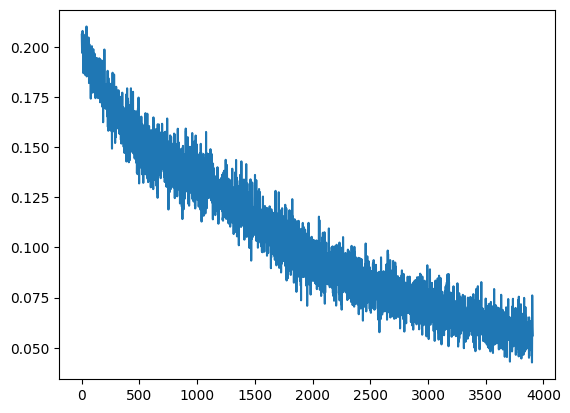

In [ ]:
plt.plot(train_losses)

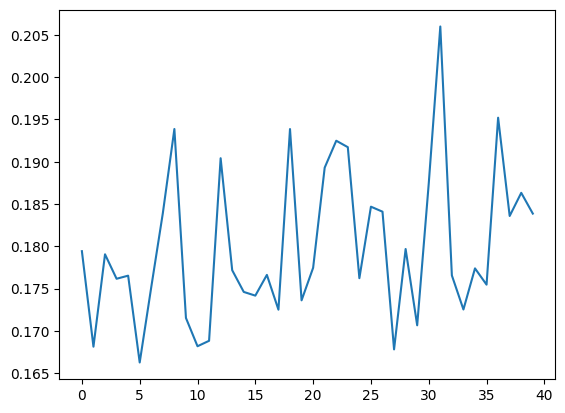

In [ ]:
plt.plot(val_losses)

# Тестируем на одной из обучающих карт

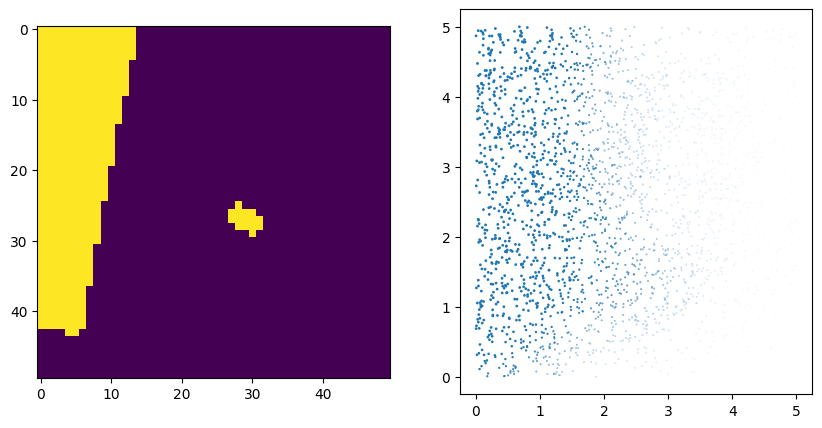

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

map_id = 1

model_answers = np.zeros((2500,5))

model.eval()
for i in range(2500):
  optimizer.zero_grad()
  inp = ((torch.tensor(train_maps[map_id,0:5]).float()/100).unsqueeze(0),
         torch.tensor(train_data[map_id,0,i,0,0]).float().unsqueeze(0).unsqueeze(0),
        torch.tensor(train_data[map_id,0,i,0,1]).float().unsqueeze(0).unsqueeze(0),
         torch.tensor(train_data[map_id,0,i,0,2]).float().unsqueeze(0).unsqueeze(0))

  inp = [i.to(device) for i in inp]
  model_output = model(*inp)
  model_answers[i] = model_output.cpu().detach().numpy()



ax1.imshow(train_maps[map_id][6])
ax2.scatter(
    x=train_data[map_id,6,:,0,0],
    y=train_data[map_id,6,:,0,1],
    s=model_answers[:,0],
)

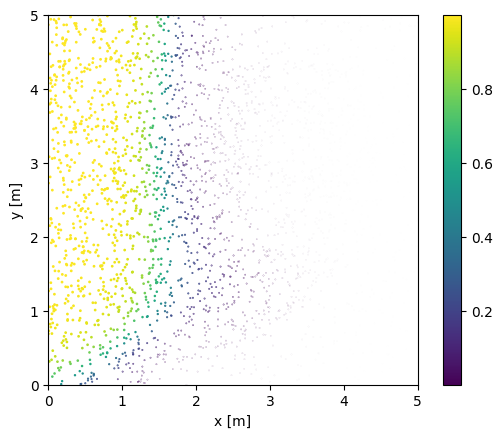

In [ ]:
# Файл .gif сохраняется в рабочей папке
gif_generate(train_data[map_id,6:], model_answers, filename='train_model_outputs')

# Тестируем на одной из валидационных карт

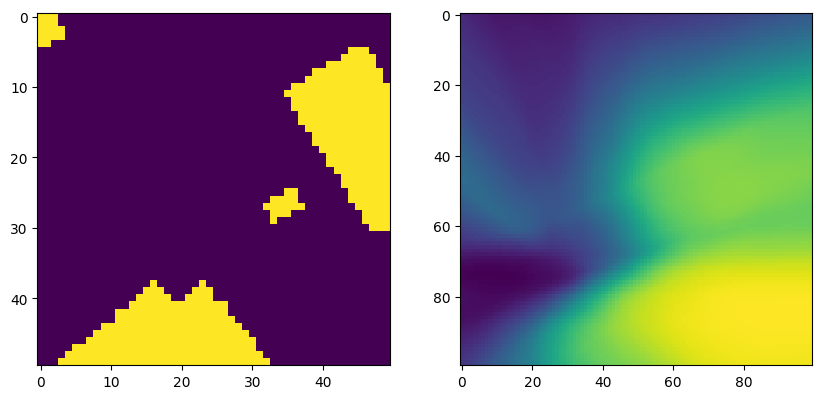

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

map_id = 1
theta = torch.tensor([2]).unsqueeze(0).float().to(device)
resolution = 100
val_answers = np.zeros((5, resolution, resolution))

model.eval()
for ii, i in enumerate(np.arange(0.0, 5, 5 / resolution)):
  for jj, j in enumerate(np.arange(0.0, 5, 5 / resolution)):
    optimizer.zero_grad()
    inp = ((torch.tensor(val_maps[map_id,0:5]).float()/100).unsqueeze(0),
          torch.tensor(i).unsqueeze(0).unsqueeze(0).to(device).float(),
          torch.tensor(j).unsqueeze(0).unsqueeze(0).to(device).float(),
          theta)

    inp = [i.to(device) for i in inp]
    model_output = model(*inp)
    val_answers[:, ii, jj] = model_output.cpu().detach().numpy()



ax1.imshow(val_maps[map_id][6])
ax2.imshow(np.rot90(val_answers[0]))

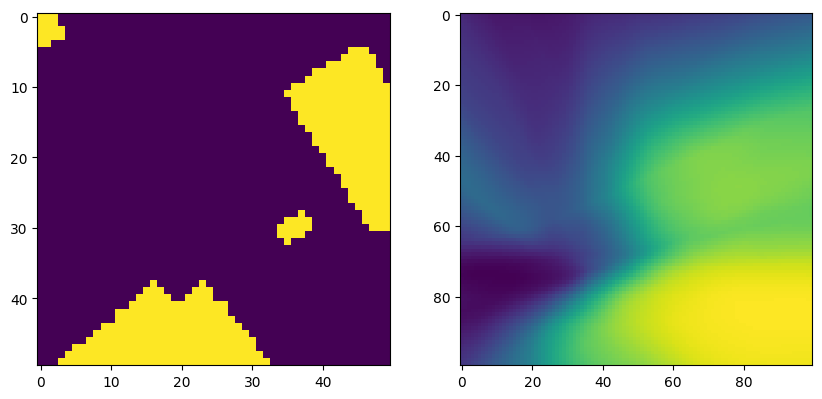

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
ax1.imshow(val_maps[map_id][6])
ax2.imshow(np.rot90(val_answers[0]))

def animate(i):
    ax1.clear()
    ax2.clear()
    ax1.imshow(val_maps[map_id][i+5])
    ax2.imshow(np.rot90(val_answers[i]))

ani = animation.FuncAnimation(fig, animate, interval=500, frames=5)

ani.save('val_model_outputs.gif', writer='pillow')

# Формируем посылку в контест

In [ ]:
load_check = torch.load(
    "model.pth",
    map_location=device)
model.load_state_dict(load_check)

<All keys matched successfully>

In [ ]:
test_maps = np.load(base_path + "/test_data/test_maps.npy")
test_data = np.load(base_path + "/test_data/test_data.npy")

print(test_maps.shape)
print(test_data.shape)

(2, 11, 50, 50)
(2, 11, 25, 4, 3)


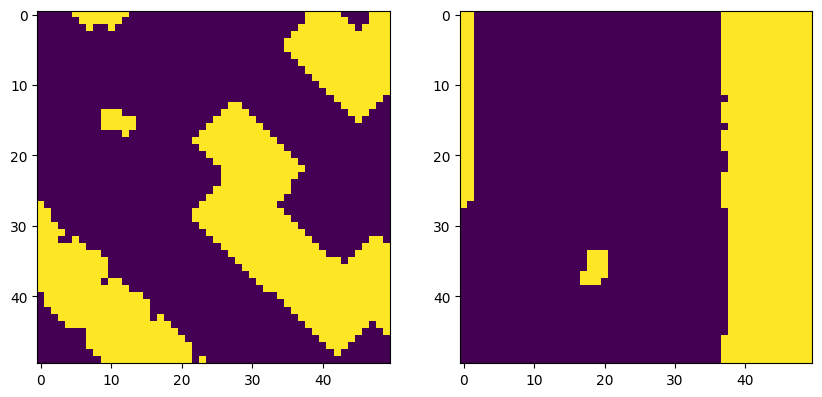

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

dyn_barrier_id = 5

ax1.imshow(test_maps[0][dyn_barrier_id])
ax2.imshow(test_maps[1][dyn_barrier_id])

In [ ]:
test_answers = np.zeros((2,25,4,5))

model.eval()
for map_id in range(2):
  for i in range(25):
    for t in range(4):
      optimizer.zero_grad()
      inp = ((torch.tensor(test_maps[map_id,0:5]).float()/100).unsqueeze(0),
            torch.tensor(test_data[map_id,0,i,t,0]).float().unsqueeze(0).unsqueeze(0),
            torch.tensor(test_data[map_id,0,i,t,1]).float().unsqueeze(0).unsqueeze(0),
            torch.tensor(test_data[map_id,0,i,t,2]).float().unsqueeze(0).unsqueeze(0))

      inp = [k.to(device) for k in inp]
      model_output = model(*inp)
      test_answers[map_id,i,t] = model_output.cpu().detach().numpy()

Сохраняем результаты

In [ ]:
df = pd.DataFrame(test_answers.reshape((2*25*4,5)))
df.to_csv(f"submission.csv", index=False)

# Посмотрим, какое качество даёт наша посылка в контесте
Этот код вы выполнить не сможете, потому что файл `test_answers` есть только у организаторов.

In [ ]:
submission = torch.from_numpy(pd.read_csv('submission.csv').values)
answers = torch.from_numpy(pd.read_csv('test_answers.csv').values)

FileNotFoundError: [Errno 2] No such file or directory: 'test_answers.csv'

In [ ]:
loss = nn.MSELoss()
score = loss(submission,answers)
print('Score is: ',score)

Score is:  tensor(0.1163, dtype=torch.float64)
